In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
TATA_clean = pd.read_csv("TATASTEEL.csv")
TATA_clean=pd.DataFrame(TATA_clean)
print(TATA_clean)


    years     Sales    CAPEX  Working capital      PBT  Interest     EBIT  \
0  2021.0  156477.0  -9437.0          44327.0  13844.0    7607.0  21451.0   
1  2022.0  243959.0 -10905.0          44381.0  50227.0    5462.0  55689.0   
2  2023.0  243353.0 -18179.0          21683.0  18235.0    6299.0  24534.0   
3  2024.0  229171.0 -14253.0          20301.0  -1147.0    7508.0   6361.0   
4  2025.0  218543.0 -13611.0          23138.0   8413.0    7341.0  15754.0   
5     NaN       NaN      NaN              NaN      NaN       NaN      NaN   

   Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  Depreciation  
0         NaN         NaN         NaN          NaN       9233.64  
1         NaN         NaN         NaN          NaN       9100.87  
2         NaN         NaN         NaN          NaN       9335.20  
3         NaN         NaN         NaN          NaN       9882.16  
4         NaN         NaN         NaN          NaN      10421.33  
5         NaN         NaN         NaN          NaN        

In [3]:
tata_rows = TATA_clean.dropna(subset=['Sales']).copy()
def run_tata_dcf(sales_growth, terminal_growth, wacc_rate):
    tata_rows['EBIT_margins'] = tata_rows['EBIT'] / tata_rows['Sales']
    tata_rows['CAPEX_ratio'] = abs(tata_rows['CAPEX']) / tata_rows['Sales']
    tata_rows['depr_ratio'] = tata_rows['Depreciation'] / tata_rows['Sales']
    tata_rows['WC_Change'] = tata_rows['Working capital'].diff().fillna(0)
    tata_rows['wc_change_ratio'] = tata_rows['WC_Change'] / tata_rows['Sales']
    avg_ebit_margin = tata_rows['EBIT_margins'].mean()
    avg_capex_ratio = tata_rows['CAPEX_ratio'].mean()
    avg_depr_ratio = tata_rows['depr_ratio'].mean()
    avg_wc_change_ratio = tata_rows['wc_change_ratio'].mean()
    
    tax_rate = 0.25
    sales_baseline = tata_rows.loc[tata_rows['years'] == 2025.0, 'Sales'].values[0]
    
    explicit_pv_sum = 0
    current_sales = sales_baseline
    
    for year in range(2026, 2031):
        current_sales *= (1 + sales_growth)
        
        p_EBIT = current_sales * avg_ebit_margin
        p_EBIAT = p_EBIT * (1 - tax_rate)
        p_depre = current_sales * avg_depr_ratio
        p_CAPEX = current_sales * avg_capex_ratio
        p_wc_change = current_sales * avg_wc_change_ratio
        
        fcf = p_EBIAT + p_depre - p_CAPEX - p_wc_change
        explicit_pv_sum += fcf / ((1 + wacc_rate) ** year)
        
    terminal_value = (fcf * (1 + terminal_growth)) / (wacc_rate - terminal_growth)
    pv_terminal_value = terminal_value / ((1 + wacc_rate) ** 5)
    enterprise_value = explicit_pv_sum + pv_terminal_value

    total_debt = 92382.0
    cash_and_equivalents = 12210.0
    shares_outstanding_crores = 1248.35
    
    equity_value = enterprise_value - total_debt + cash_and_equivalents
    intrinsic_value = equity_value / shares_outstanding_crores
    
    return intrinsic_value

base_growth = 0.06          
base_terminal = 0.045        
base_wacc = 0.1350          

base_target = run_tata_dcf(base_growth, base_terminal, base_wacc)
print(f"Base Case Target Stock Price: ₹{base_target:.2f}\n")

Base Case Target Stock Price: ₹122.43



In [6]:
sensitivity_grid = [
    {"Model Parameter Evaluated": "WACC Cost of Capital (Base: 13.50%)",
     "Minus 1.00% Downside Shift": run_tata_dcf(base_growth, base_terminal, base_wacc - 0.01),
      "Plus 1.00% Upside Shift": run_tata_dcf(base_growth, base_terminal, base_wacc + 0.01)},
        {"Model Parameter Evaluated": "Revenue Growth Rate (Base: 6.00%)",
        "Minus 1.00% Downside Shift": run_tata_dcf(base_growth - 0.01, base_terminal, base_wacc),
        "Plus 1.00% Upside Shift": run_tata_dcf(base_growth + 0.01, base_terminal, base_wacc)},
    {"Model Parameter Evaluated": "Terminal Growth Rate (Base: 4.50%)",
        "Minus 1.00% Downside Shift": run_tata_dcf(base_growth, base_terminal - 0.01, base_wacc),
        "Plus 1.00% Upside Shift": run_tata_dcf(base_growth, base_terminal + 0.01, base_wacc)}]

df_sens = pd.DataFrame(sensitivity_grid)


df_sens["Total Price Impact Range"] = abs(df_sens["Plus 1.00% Upside Shift"] - df_sens["Minus 1.00% Downside Shift"])
df_sens = df_sens.sort_values(by="Total Price Impact Range", ascending=False)

print(df_sens.to_string(index=False, formatters={
    "Minus 1.00% Downside Shift": "₹{:.2f}".format,
    "Plus 1.00% Upside Shift": "₹{:.2f}".format,
    "Total Price Impact Range": "₹{:.2f}".format}))

          Model Parameter Evaluated Minus 1.00% Downside Shift Plus 1.00% Upside Shift Total Price Impact Range
WACC Cost of Capital (Base: 13.50%)                    ₹145.97                 ₹103.61                   ₹42.36
 Terminal Growth Rate (Base: 4.50%)                    ₹108.88                 ₹139.37                   ₹30.49
  Revenue Growth Rate (Base: 6.00%)                    ₹115.01                 ₹130.12                   ₹15.11


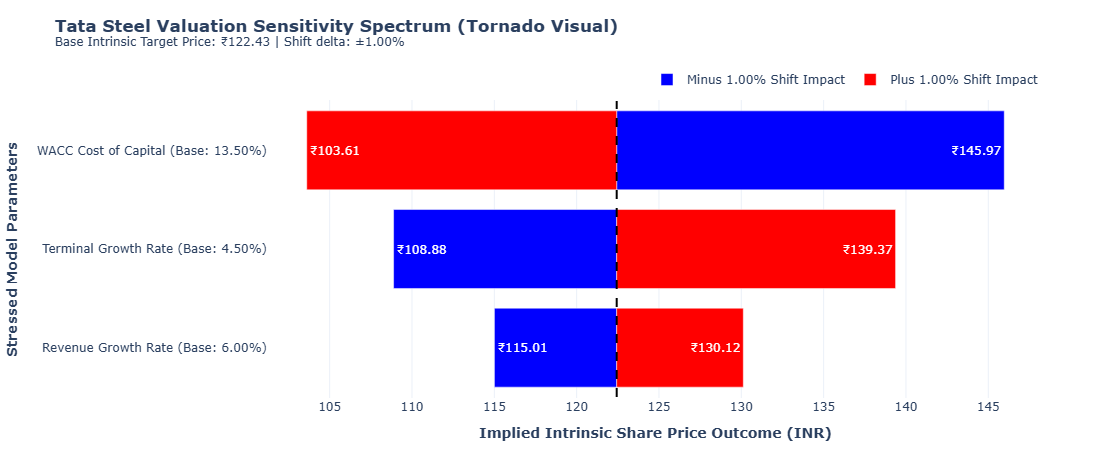

In [9]:
import plotly.graph_objects as go

baseline_anchor = base_target 
df_plot = df_sens.sort_values(by="Total Price Impact Range", ascending=True)
fig = go.Figure()
fig.add_trace(go.Bar(
    y=df_plot["Model Parameter Evaluated"],
    x=df_plot["Minus 1.00% Downside Shift"] - baseline_anchor,
    base=baseline_anchor,
    marker_color='blue', # 
    name='Minus 1.00% Shift Impact',
    orientation='h',
    text=df_plot["Minus 1.00% Downside Shift"].apply(lambda x: f"₹{x:.2f}"),
    textposition='inside',
    hovertemplate="Variable: %{y}<br>Implied Price: %{text}<extra></extra>"))
fig.add_trace(go.Bar(
    y=df_plot["Model Parameter Evaluated"],
    x=df_plot["Plus 1.00% Upside Shift"] - baseline_anchor,
    base=baseline_anchor,
    marker_color='red', 
    name='Plus 1.00% Shift Impact',
    orientation='h',
    text=df_plot["Plus 1.00% Upside Shift"].apply(lambda x: f"₹{x:.2f}"),
    textposition='inside',
    hovertemplate="Variable: %{y}<br>Implied Price: %{text}<extra></extra>"))
fig.update_layout(
    title=
    {'text': f"<b>Tata Steel Valuation Sensitivity Spectrum (Tornado Visual)</b><br><sup>Base Intrinsic Target Price: ₹{baseline_anchor:.2f} | Shift delta: ±1.00%</sup>",
        'y': 0.93, 'x': 0.05, 'xanchor': 'left', 'yanchor': 'top'},
    barmode='overlay', 
    xaxis_title="<b>Implied Intrinsic Share Price Outcome (INR)</b>",
    yaxis_title="<b>Stressed Model Parameters</b>",
    template="plotly_white",
    height=450,
    margin=dict(t=100, b=50, l=50, r=50),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

fig.add_shape(
    type="line", 
    x0=baseline_anchor, y0=-0.5, 
    x1=baseline_anchor, y1=len(df_plot) - 0.5,
    line=dict(color="black", width=2, dash="dash"))

fig.show()

In [10]:
Infosys = pd.read_csv("INFOSYS.csv")
INFOSYS=pd.DataFrame(Infosys)

print(INFOSYS)

    years     Sales  Working capital      PBT  Interest     EBIT   CAPEX  \
0  2021.0  100472.0          23224.0  26628.0     195.0  26823.0 -7373.0   
1  2022.0  121641.0          23885.0  30110.0     200.0  30310.0 -6485.0   
2  2023.0  146767.0          22467.0  33322.0     284.0  33606.0 -1071.0   
3  2024.0  153670.0          25210.0  35988.0     470.0  36458.0 -5093.0   
4  2025.0  162990.0          35694.0  37608.0     416.0  38024.0 -1864.0   
5     NaN       NaN              NaN      NaN       NaN      NaN     NaN   

   Depreciation  
0        3266.0  
1        4182.0  
2        4225.0  
3        4678.0  
4        4812.0  
5           NaN  


In [13]:
infy_rows =INFOSYS.dropna(subset=['Sales']).copy()
def run_infosys_dcf(sales_growth, terminal_growth, wacc_rate):
    infy_rows['EBIT_margins'] = infy_rows['EBIT'] / infy_rows['Sales']
    infy_rows['CAPEX_ratio'] = abs(infy_rows['CAPEX']) / infy_rows['Sales']
    infy_rows['depr_ratio'] = infy_rows['Depreciation'] / infy_rows['Sales']
    infy_rows['WC_Change'] = infy_rows['Working capital'].diff().fillna(0)
    infy_rows['wc_change_ratio'] = infy_rows['WC_Change'] / infy_rows['Sales']
    avg_ebit_margin = infy_rows['EBIT_margins'].mean()
    avg_capex_ratio = infy_rows['CAPEX_ratio'].mean()
    avg_depr_ratio = infy_rows['depr_ratio'].mean()
    avg_wc_change_ratio = infy_rows['wc_change_ratio'].mean()
    tax_rate = 0.25
    sales_baseline = infy_rows.loc[infy_rows['years'] == 2025.0, 'Sales'].values[0]
    explicit_pv_sum = 0
    current_sales = sales_baseline
    for idx, year in enumerate(range(2026, 2031), start=1):
        current_sales *= (1 + sales_growth)
        
        p_EBIT = current_sales * avg_ebit_margin
        p_EBIAT = p_EBIT * (1 - tax_rate)
        p_depre = current_sales * avg_depr_ratio
        p_CAPEX = current_sales * avg_capex_ratio
        p_wc_change = current_sales * avg_wc_change_ratio
        
        fcf = p_EBIAT + p_depre - p_CAPEX - p_wc_change
        explicit_pv_sum += fcf / ((1 + wacc_rate) ** idx)
    terminal_value = (fcf * (1 + terminal_growth)) / (wacc_rate - terminal_growth)
    pv_terminal_value = terminal_value / ((1 + wacc_rate) ** 5)
    enterprise_value = explicit_pv_sum + pv_terminal_value
    total_debt = 9119.0                
    cash_and_equivalents = 43075.0      
    shares_outstanding_crores = 404.69  
    equity_value = enterprise_value - total_debt + cash_and_equivalents
    intrinsic_value = equity_value / shares_outstanding_crores
    
    return intrinsic_value
base_growth = 0.07          
base_terminal = 0.045       
base_wacc = 0.1315          

base_target = run_infosys_dcf(base_growth, base_terminal, base_wacc)
print(f"Infosys Base Case Target Stock Price: ₹{base_target:.2f}")

Infosys Base Case Target Stock Price: ₹957.65


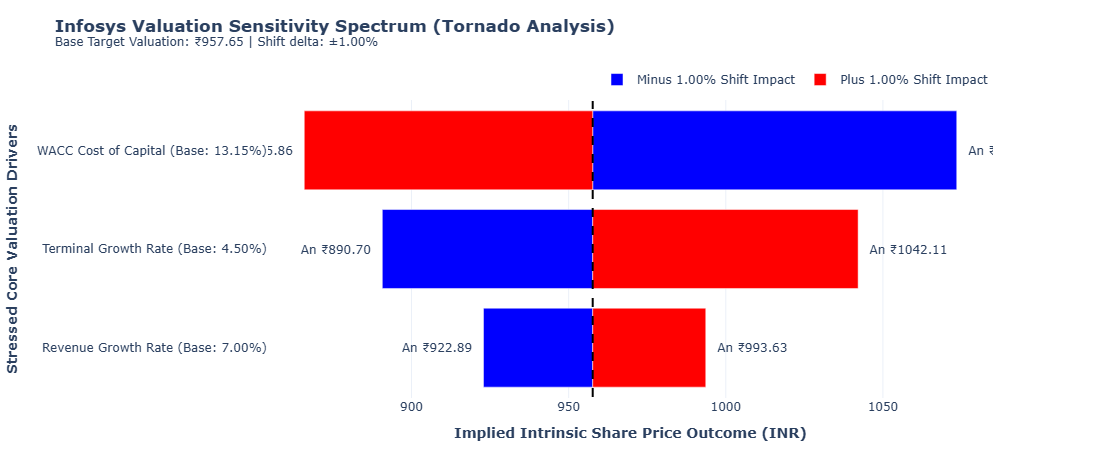

In [15]:
sensitivity_grid = [
    {"Model Parameter Evaluated": "WACC Cost of Capital (Base: 13.15%)",
        "Minus 1.00% Downside Shift": run_infosys_dcf(base_growth, base_terminal, base_wacc - 0.01),
        "Plus 1.00% Upside Shift": run_infosys_dcf(base_growth, base_terminal, base_wacc + 0.01)},
    { "Model Parameter Evaluated": "Revenue Growth Rate (Base: 7.00%)",
        "Minus 1.00% Downside Shift": run_infosys_dcf(base_growth - 0.01, base_terminal, base_wacc),
        "Plus 1.00% Upside Shift": run_infosys_dcf(base_growth + 0.01, base_terminal, base_wacc)},
    {"Model Parameter Evaluated": "Terminal Growth Rate (Base: 4.50%)",
        "Minus 1.00% Downside Shift": run_infosys_dcf(base_growth, base_terminal - 0.01, base_wacc),
        "Plus 1.00% Upside Shift": run_infosys_dcf(base_growth, base_terminal + 0.01, base_wacc)}]

df_sens = pd.DataFrame(sensitivity_grid)

df_sens["Total Price Impact Range"] = abs(df_sens["Plus 1.00% Upside Shift"] - df_sens["Minus 1.00% Downside Shift"])
df_plot = df_sens.sort_values(by="Total Price Impact Range", ascending=True)

fig = go.Figure()

fig.add_trace(go.Bar(
    y=df_plot["Model Parameter Evaluated"],
    x=df_plot["Minus 1.00% Downside Shift"] - base_target,
    base=base_target,
    marker_color='blue',
    name='Minus 1.00% Shift Impact',
    orientation='h',
    text=df_plot["Minus 1.00% Downside Shift"].apply(lambda x: f"  An ₹{x:.2f}  "),
    textposition='outside'))
fig.add_trace(go.Bar(
    y=df_plot["Model Parameter Evaluated"],
    x=df_plot["Plus 1.00% Upside Shift"] - base_target,
    base=base_target,
    marker_color='red',
    name='Plus 1.00% Shift Impact',
    orientation='h',
    text=df_plot["Plus 1.00% Upside Shift"].apply(lambda x: f"  An ₹{x:.2f}  "),
    textposition='outside'))
fig.update_layout(
    title={
        'text': f"<b>Infosys Valuation Sensitivity Spectrum (Tornado Analysis)</b><br><sup>Base Target Valuation: ₹{base_target:.2f} | Shift delta: ±1.00%</sup>",
        'y': 0.93, 'x': 0.05, 'xanchor': 'left', 'yanchor': 'top'},
    barmode='overlay',
    xaxis_title="<b>Implied Intrinsic Share Price Outcome (INR)</b>",
    yaxis_title="<b>Stressed Core Valuation Drivers</b>",
    template="plotly_white",
    height=450,
    margin=dict(t=100, b=50, l=220, r=100), 
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))
fig.add_shape(
    type="line", 
    x0=base_target, y0=-0.5, 
    x1=base_target, y1=len(df_plot) - 0.5,
    line=dict(color="black", width=2, dash="dash"))

fig.show()

          Metric Bounds TATA STEEL  INFOSYS
 Minimum Price Observed     ₹85.38  ₹798.97
  25th Percentile Floor    ₹113.72  ₹911.24
Expected Mean (Average)    ₹123.64  ₹960.19
    75th Percentile Cap    ₹132.51 ₹1003.53
 Maximum Price Observed    ₹178.44 ₹1239.34


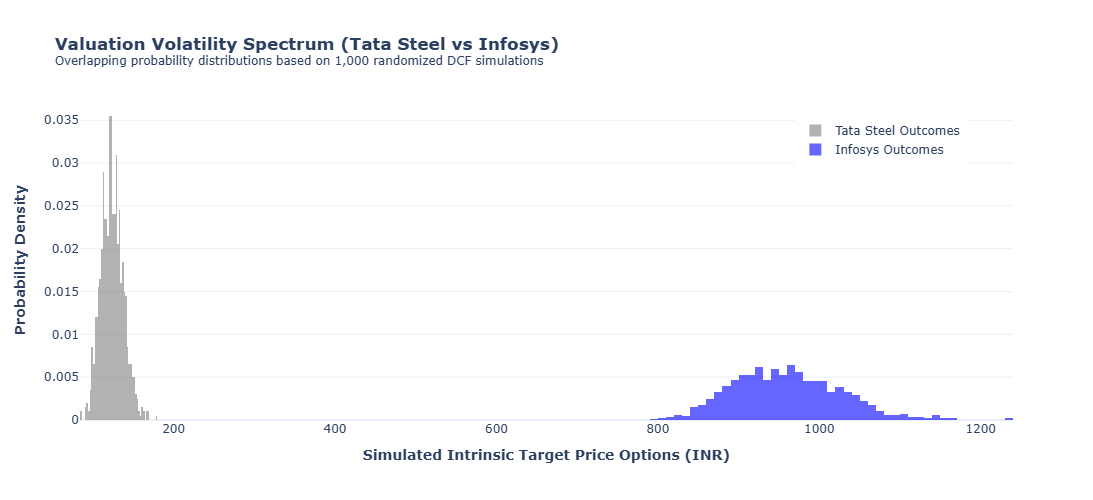

In [18]:
np.random.seed(42)  
iterations = 1000
tata_wacc_sim = np.random.normal(loc=0.1350, scale=0.005, size=iterations)
tata_growth_sim = np.random.normal(loc=0.06, scale=0.01, size=iterations)
tata_term_sim = np.random.normal(loc=0.045, scale=0.003, size=iterations)
infy_wacc_sim = np.random.normal(loc=0.1315, scale=0.005, size=iterations)
infy_growth_sim = np.random.normal(loc=0.07, scale=0.01, size=iterations)
infy_term_sim = np.random.normal(loc=0.045, scale=0.003, size=iterations)
tata_final_prices = []
infy_final_prices = []
for i in range(iterations):
    p_tata = run_tata_dcf(tata_growth_sim[i], tata_term_sim[i], tata_wacc_sim[i])
    if not np.isnan(p_tata) and p_tata > 0:
        tata_final_prices.append(p_tata)
    p_infy = run_infosys_dcf(infy_growth_sim[i], infy_term_sim[i], infy_wacc_sim[i])
    if not np.isnan(p_infy) and p_infy > 0:
        infy_final_prices.append(p_infy)
df_tata_mc = pd.Series(tata_final_prices)
df_infy_mc = pd.Series(infy_final_prices)
mc_summary = pd.DataFrame({
    "Metric Bounds": ["Minimum Price Observed", "25th Percentile Floor", "Expected Mean (Average)", "75th Percentile Cap", "Maximum Price Observed"],
    "TATA STEEL": [df_tata_mc.min(), df_tata_mc.quantile(0.25), df_tata_mc.mean(), df_tata_mc.quantile(0.75), df_tata_mc.max()],
    "INFOSYS": [df_infy_mc.min(), df_infy_mc.quantile(0.25), df_infy_mc.mean(), df_infy_mc.quantile(0.75), df_infy_mc.max()]})
print(mc_summary.to_string(index=False, formatters={"TATA STEEL": "₹{:.2f}".format, "INFOSYS": "₹{:.2f}".format}))

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=tata_final_prices,
    nbinsx=50,
    name='Tata Steel Outcomes',
    marker_color='grey',
    opacity=0.6,
    histnorm='probability density'))


fig.add_trace(go.Histogram(
    x=infy_final_prices,
    nbinsx=50,
    name='Infosys Outcomes',
    marker_color='blue',
    opacity=0.6,
    histnorm='probability density'))

fig.update_layout(
    title="<b>Valuation Volatility Spectrum (Tata Steel vs Infosys)</b><br><sup>Overlapping probability distributions based on 1,000 randomized DCF simulations</sup>",
    xaxis_title="<b>Simulated Intrinsic Target Price Options (INR)</b>",
    yaxis_title="<b>Probability Density</b>",
    barmode='overlay',  
    template="plotly_white",
    height=500,
    legend=dict(yanchor="top", y=0.95, xanchor="right", x=0.95))

fig.show()